In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
le = LabelEncoder()

df["Attrition"] = le.fit_transform(df["Attrition"])
df["Gender"] = le.fit_transform(df["Gender"])
df["OverTime"] = le.fit_transform(df["OverTime"])

In [4]:
df.drop(
    columns=["Over18"],
    inplace=True,
    errors="ignore"
)

In [5]:
multi_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus"
]

df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True
)

In [6]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [9]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = rf.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8775510204081632


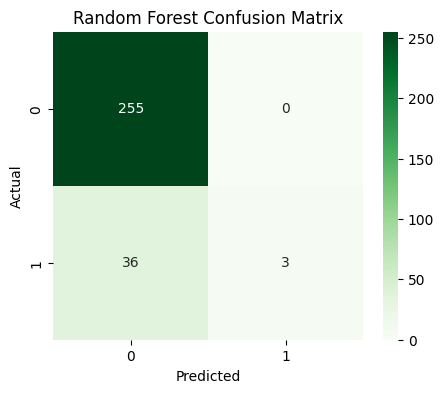

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       1.00      0.08      0.14        39

    accuracy                           0.88       294
   macro avg       0.94      0.54      0.54       294
weighted avg       0.89      0.88      0.83       294



In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
12,MonthlyIncome,0.076956
15,OverTime,0.060692
0,Age,0.051345
1,DailyRate,0.049777
21,TotalWorkingYears,0.045616
5,EmployeeNumber,0.045519
13,MonthlyRate,0.044227
8,HourlyRate,0.042277
24,YearsAtCompany,0.040692
2,DistanceFromHome,0.039103


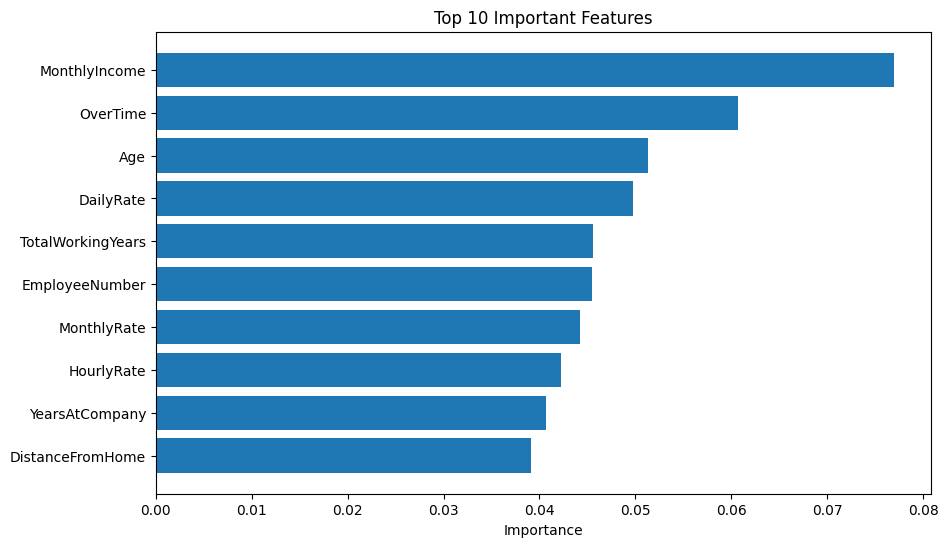

In [15]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [16]:
print("Top 10 Important Features:\n")

print(importance.head(10))

Top 10 Important Features:

              Feature  Importance
12      MonthlyIncome    0.076956
15           OverTime    0.060692
0                 Age    0.051345
1           DailyRate    0.049777
21  TotalWorkingYears    0.045616
5      EmployeeNumber    0.045519
13        MonthlyRate    0.044227
8          HourlyRate    0.042277
24     YearsAtCompany    0.040692
2    DistanceFromHome    0.039103


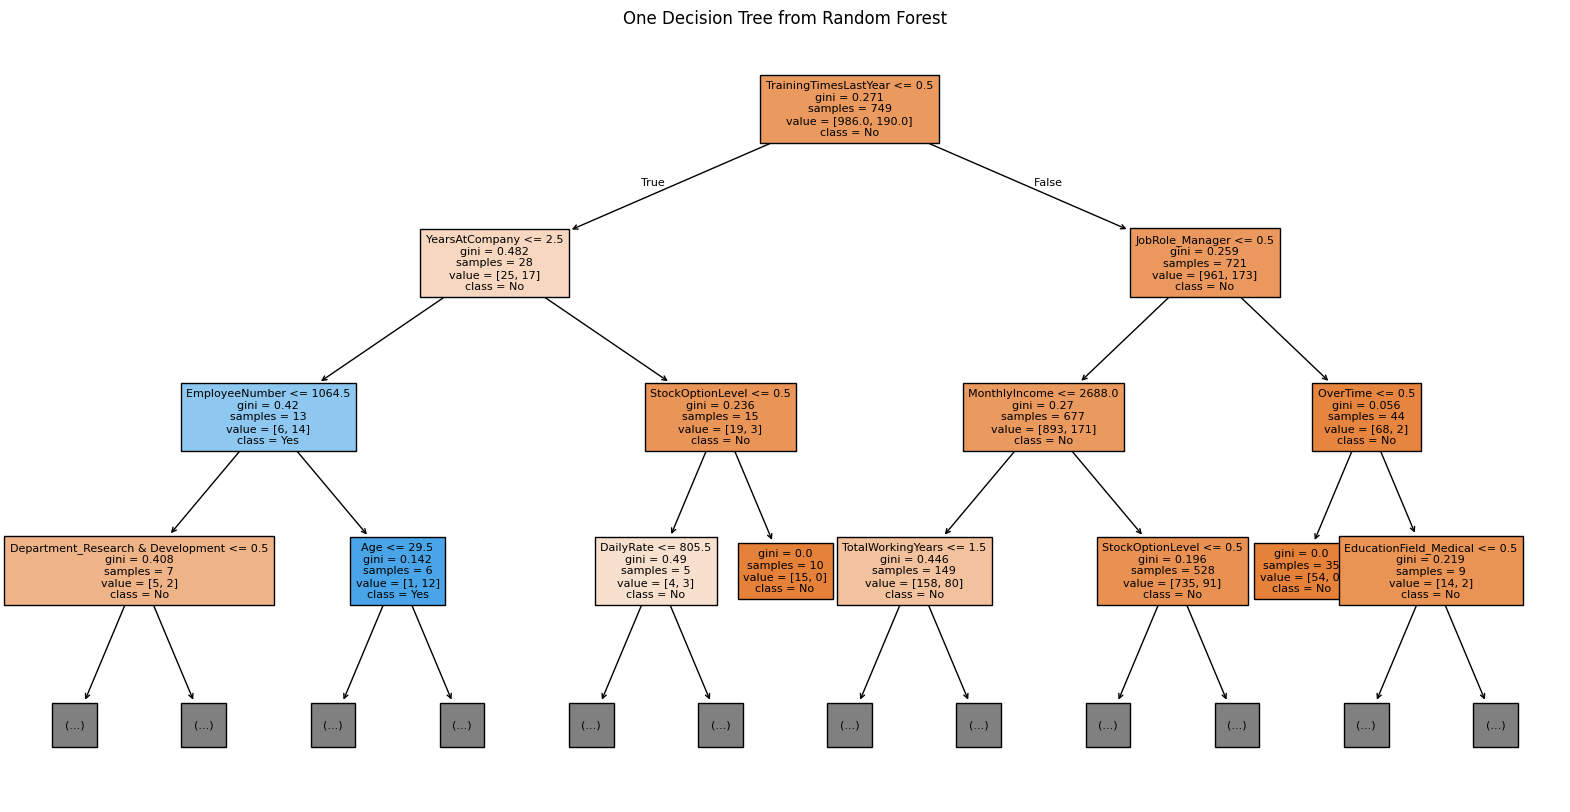

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("One Decision Tree from Random Forest")

plt.show()